# Solution: statistiques de base

Une solution possible pour chaque exercice. Plusieurs formulations sont souvent valides.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
chronos = pd.Series(rng.normal(loc=55, scale=8, size=30).round(1))
chronos

0     57.4
1     46.7
2     61.0
3     62.5
4     39.4
5     44.6
6     56.0
7     52.5
8     54.9
9     48.2
10    62.0
11    61.2
12    55.5
13    64.0
14    58.7
15    48.1
16    58.0
17    47.3
18    62.0
19    54.6
20    53.5
21    49.6
22    64.8
23    53.8
24    51.6
25    52.2
26    59.3
27    57.9
28    58.3
29    58.4
dtype: float64

## Tendance centrale

In [2]:
# TODO : Calculer et afficher la moyenne des chronos (méthode .mean()).

print(f"Moyenne = {chronos.mean():.2f} min")

Moyenne = 55.13 min


In [3]:
# TODO : Calculer et afficher la médiane des chronos (méthode .median()).

print(f"Médiane = {chronos.median():.2f} min")

Médiane = 55.75 min


In [4]:
# TODO : Comparer moyenne et médiane.
# Sont-elles proches ? Pourquoi à votre avis ?

# La distribution étant générée à partir d'une loi normale, elle est
# globalement symétrique. Moyenne et médiane sont donc proches
# (à quelques dixièmes de minute près) — l'écart vient juste du fait
# qu'on n'a que 30 échantillons.
print(f"Moyenne = {chronos.mean():.2f}, Médiane = {chronos.median():.2f}")

Moyenne = 55.13, Médiane = 55.75


## Effet d'une valeur aberrante (outlier)

Un coureur s'est blessé en cours de route et a mis **3 heures** (soit 180 minutes) pour finir. On l'ajoute à la série.

In [5]:
chronos_avec_outlier = pd.concat([chronos, pd.Series([180.0])], ignore_index=True)
chronos_avec_outlier.tail()

26     59.3
27     57.9
28     58.3
29     58.4
30    180.0
dtype: float64

In [6]:
# TODO : Recalculer la moyenne et la médiane de `chronos_avec_outlier`.
# Laquelle des deux a le plus bougé par rapport à la série d'origine ?

print(f"Moyenne avec outlier  = {chronos_avec_outlier.mean():.2f}")
print(f"Médiane avec outlier  = {chronos_avec_outlier.median():.2f}")

# La moyenne a bougé de ~4 min, la médiane à peine. La médiane est
# robuste aux outliers ; la moyenne, non.

Moyenne avec outlier  = 59.16
Médiane avec outlier  = 56.00


````{admonition} 💡 À retenir
:class: tip
La **médiane** résiste mieux aux valeurs aberrantes que la **moyenne**. C'est pour cela qu'on l'utilise souvent quand les données contiennent des outliers (par exemple : revenus, prix immobiliers, temps de réponse réseau).
````

## Variabilité

In [7]:
# TODO : Afficher le minimum, le maximum et l'étendue (max - min) des chronos.

print(f"Min      = {chronos.min():.2f}")
print(f"Max      = {chronos.max():.2f}")
print(f"Étendue  = {chronos.max() - chronos.min():.2f}")

Min      = 39.40
Max      = 64.80
Étendue  = 25.40


In [8]:
# TODO : Calculer l'écart-type des chronos (méthode .std()).
# Que représente-t-il intuitivement ?

print(f"Écart-type = {chronos.std():.2f} min")

# Intuitivement, l'écart-type mesure de combien les chronos s'écartent
# typiquement de la moyenne. Ici, environ 7-8 min — cohérent avec
# le `scale=8` qu'on a passé au générateur.

Écart-type = 6.20 min


In [9]:
# TODO : À l'aide de np.quantile(), calculer le 25e percentile (Q1)
# et le 75e percentile (Q3) des chronos.
# En déduire l'écart interquartile (IQR = Q3 - Q1).

q1 = np.quantile(chronos, 0.25)
q3 = np.quantile(chronos, 0.75)
iqr = q3 - q1
print(f"Q1  = {q1:.2f}")
print(f"Q3  = {q3:.2f}")
print(f"IQR = {iqr:.2f}")

Q1  = 51.75
Q3  = 59.15
IQR = 7.40


## Comparaison de deux groupes

Voici les chronos d'un second groupe de coureurs (30 personnes) qui se sont préparés davantage :

In [10]:
chronos_entraine = pd.Series(rng.normal(loc=48, scale=4, size=30).round(1))
chronos_entraine.head()

0    56.6
1    46.4
2    46.0
3    44.7
4    50.5
dtype: float64

In [11]:
# TODO : Comparer les deux groupes :
#   - Lequel a la meilleure moyenne ?
#   - Lequel est le plus régulier (écart-type le plus faible) ?

for nom, serie in [("non entraîné", chronos), ("entraîné", chronos_entraine)]:
    print(f"{nom:15s} → moyenne = {serie.mean():.2f} min,"
          f" écart-type = {serie.std():.2f} min")

# Le groupe entraîné a une meilleure moyenne (chronos plus faibles)
# ET un écart-type plus petit (résultats plus homogènes).

non entraîné    → moyenne = 55.13 min, écart-type = 6.20 min
entraîné        → moyenne = 48.46 min, écart-type = 3.23 min


## Distribution

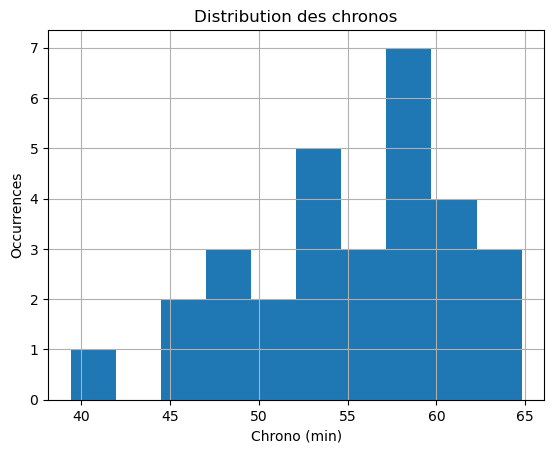

In [12]:
# TODO : Tracer un histogramme des chronos d'origine (sans outlier).

chronos.hist(bins=10)
plt.xlabel("Chrono (min)")
plt.ylabel("Occurrences")
plt.title("Distribution des chronos")
plt.show()

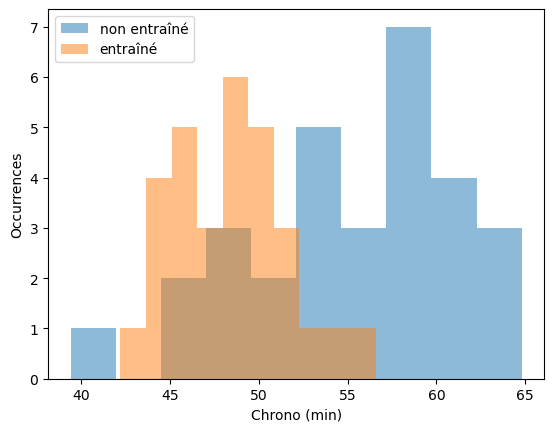

In [13]:
# TODO : Sur le même graphique, superposer l'histogramme du groupe entraîné.

plt.hist(chronos, bins=10, alpha=0.5, label="non entraîné")
plt.hist(chronos_entraine, bins=10, alpha=0.5, label="entraîné")
plt.xlabel("Chrono (min)")
plt.ylabel("Occurrences")
plt.legend()
plt.show()

# On voit clairement que le groupe entraîné est décalé vers la
# gauche (chronos plus rapides) et plus resserré (moins dispersé).